# Food Insecurity Phases Optimization and Analytics  
### Second Notebook: Optimization Modeling and Resource Allocation

This notebook builds on the data preparation and exploratory analysis conducted in the first phase of the project. It focuses on developing and implementing an optimization model to support **humanitarian resource allocation under constraints**.

Using a structured dataset of country-level populations distributed across food insecurity phases, this notebook translates analytical insights into a **mathematical decision-making framework**. The approach leverages severity-informed indicators to prioritize interventions and allocate limited resources efficiently.

The objective of this notebook is to design, formulate, and solve an optimization problem that determines how to distribute resources across countries in a way that maximizes humanitarian impact. The model incorporates key elements such as **budget constraints, prioritization metrics, and allocation rules**, ensuring realistic and actionable outcomes.

The optimization results are then analyzed to generate **actionable insights**, highlighting optimal allocation strategies, trade-offs, and priority countries for intervention. These insights aim to support evidence-based decision-making in humanitarian contexts.

The overall goal is to move from **data-driven analysis to prescriptive analytics**, enabling optimal resource allocation decisions grounded in both the **scale and severity of food insecurity**.

**Author:** J-F J  
**Date:** April 2026  
**Dataset:** Food Insecurity Phase Dataset (processed and structured for optimization)

## 2.1-Data Loading and Overview

In [1]:
import pandas as pd

# File path (Kaggle dataset)
file_path = "/kaggle/input/datasets/jfjutras07/food-insecurity-modified/food_insecurity_clean.csv"

# Load dataset
df = pd.read_csv(file_path)

# Preview
display(df.head())
display(df.tail())
df.info()

,Country,1,2,3,4,5,total_population,critical_pop,critical_ratio,hybrid_score
0,NGA,104204933,86515838,26355367,857567,0,217933705,27212934,0.124868,3.398023e+06
1,PSE,0,475345,989840,507015,103800,2076000,1600655,0.771028,1.234150e+06
2,CMR,20099416,6194078,2871964,249306,0,29414764,3121270,0.106112,3.312053e+05
3,TCD,12227264,3915887,1831960,95621,0,18070731,1927581,0.106669,2.056125e+05
4,GIN,8295152,2638957,1426708,53948,0,12414765,1480656,0.119266,1.765915e+05


,Country,1,2,3,4,5,total_population,critical_pop,critical_ratio,hybrid_score
10,MRT,4176071,1036606,361004,33115,0,5606796,394119,0.070293,27703.841224
11,BEN,2133087,447323,188147,2960,0,2771518,191107,0.068954,13177.574690
12,SEN,16639064,2430539,491101,13285,0,19573989,504386,0.025768,12997.107386
13,TGO,5009261,1171968,288383,0,0,6469612,288383,0.044575,12854.674235
14,CPV,394204,82042,37752,0,0,513997,37752,0.073448,2772.805102


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           15 non-null     object 
 1   1                 15 non-null     int64  
 2   2                 15 non-null     int64  
 3   3                 15 non-null     int64  
 4   4                 15 non-null     int64  
 5   5                 15 non-null     int64  
 6   total_population  15 non-null     int64  
 7   critical_pop      15 non-null     int64  
 8   critical_ratio    15 non-null     float64
 9   hybrid_score      15 non-null     float64
dtypes: float64(2), int64(7), object(1)
memory usage: 1.3+ KB


## 2.2-Humanitarian Allocation Framework

In humanitarian decision-making under scarcity, resource allocation cannot rely solely on the number of affected individuals. Instead, it requires a structured representation of vulnerability that integrates severity, population exposure, and forward-looking risk.

This project adopts a simplified analytical framework designed to transform food insecurity indicators into an optimization-ready structure suitable for constrained allocation problems.

### Operational Proxy Design (Model Simplification)

Given data limitations, the framework is operationalized through three synthetic components derived from phase distribution and population exposure. These proxies are designed to approximate humanitarian impact, economic burden, and forward-looking vulnerability in a structured and interpretable way.

**Health Impact Proxy**

Represents avoided adverse health outcomes such as acute malnutrition, disease susceptibility, and mortality risk associated with food insecurity severity.

**Economic Burden Proxy**

Represents avoided indirect economic losses, including emergency response costs, healthcare system burden, and productivity losses associated with worsening food insecurity conditions.

**Risk of Deterioration Proxy**

Represents a composite vulnerability and fragility measure capturing the likelihood that a given context will worsen over time. This includes structural instability, limited humanitarian access, logistical constraints, and exposure to external shocks. It reflects not only current severity, but also the ease with which conditions may deteriorate further or become harder to intervene in.

### Composite Humanitarian Utility Function

To enable optimization under constrained resources, the three proxy dimensions are combined into a single composite utility function. This function represents the total humanitarian value generated by allocating resources to a given country or population group.

The objective is to maximize overall humanitarian impact while balancing health outcomes, economic burden reduction, and forward-looking risk mitigation.

```text
Total Impact Score =
w1 × Health Impact +
w2 × Economic Impact +
w3 × Risk Impact

### Feature Engineering

In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = df.copy()

# Population
pop = df["total_population"]

# Health Impact Proxy (Focus on acute malnutrition and mortality risks)
df["health_impact"] = (
    df["3"] * 1.0 +
    df["4"] * 4.0 +
    df["5"] * 10.0
)

# Economic Impact Proxy (Focus on loss of livelihoods and emergency response costs)
df["economic_impact"] = (
    df["3"] * 1.0 +
    df["4"] * 2.5 +
    df["5"] * 6.0
)

# Risk / Vulnerability Proxy (Reflecting potential for rapid deterioration)
df["risk_impact"] = (
    df["2"] * 0.2 +
    df["3"] * 1.0 +
    df["4"] * 3.0 +
    df["5"] * 8.0
)

# Normalize impacts
scaler = MinMaxScaler()

df[["health_impact", "economic_impact", "risk_impact"]] = scaler.fit_transform(
    df[["health_impact", "economic_impact", "risk_impact"]]
)

# Composite score
w1, w2, w3 = 0.5, 0.25, 0.25

df["total_impact_score"] = (
    w1 * df["health_impact"] +
    w2 * df["economic_impact"] +
    w3 * df["risk_impact"]
)

# Cost

severity_cost = (
    df["1"] * 1 +
    df["2"] * 2 +
    df["3"] * 5 +
    df["4"] * 12 +
    df["5"] * 30
)

df["cost_per_person"] = severity_cost / (pop + 1e-6)

## 2.3-Budget Definition and Cost Structure

In this section, we define the total available humanitarian budget and construct a severity-weighted cost structure to approximate the relative resource intensity required across contexts. This cost function serves as the foundation for later optimization by translating phase distributions into a normalized intervention cost proxy.

In [3]:
# Total humanitarian budget (scenario parameter)
TOTAL_BUDGET = 1_000_000

# Define a base cost per person for a standard intervention
BASE_UNIT_COST = 50 

# Calculate a severity multiplier 
# This scales the cost based on the complexity of the phases
# Phase 5 is much more expensive to treat than Phase 3
severity_multiplier = (
    df["1"] * 0.1 + 
    df["2"] * 0.5 + 
    df["3"] * 1.0 + 
    df["4"] * 2.0 + 
    df["5"] * 5.0
) / (df["total_population"] + 1e-6)

# Final cost per person in USD
# We ensure a minimum cost (e.g., $10) and scale it by severity
df["cost_per_person"] = 10 + (severity_multiplier * BASE_UNIT_COST)

# Normalization
from sklearn.preprocessing import MinMaxScaler
scaler_cost = MinMaxScaler()
df["cost_per_person_norm"] = scaler_cost.fit_transform(df[["cost_per_person"]])

# Safety check
assert df["cost_per_person"].min() > 0

## 2.4-Optimization Model

The optimization model allocates limited humanitarian resources across countries by maximizing a weighted impact objective under a normalized budget constraint. Allocation decisions are driven by the trade-off between humanitarian impact and intervention cost efficiency.

In [4]:
from scipy.optimize import linprog

# Objective: maximize humanitarian impact per dollar spent
# impact_per_dollar = total_impact_score / cost_per_person
impact_per_dollar = df["total_impact_score"].values / (df["cost_per_person"].values + 1e-6)
c = -impact_per_dollar

# Total budget
B = TOTAL_BUDGET

# Constraints: 
# 1. Budget: sum of all allocations <= TOTAL_BUDGET
# 2. Presence: Each country gets at least $15,000
# 3. Capacity: No country gets more than 25% of the total budget
A_ub = [[1] * len(df)]
b_ub = [B]
bounds = [(15000, B * 0.25) for _ in range(len(df))]

# Solve
result = linprog(
    c=c,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method="highs"
)

# Store results
if not result.success:
    raise ValueError(f"Optimization failed: {result.message}")

df["allocation_budget"] = result.x

# Derived metrics for analysis
df["people_helped_est"] = df["allocation_budget"] / df["cost_per_person"]
df["weighted_impact"] = df["people_helped_est"] * df["total_impact_score"]

# Ranking
df_sorted = df.sort_values("allocation_budget", ascending=False)

display(df_sorted[[
    "Country",
    "allocation_budget",
    "total_impact_score",
    "cost_per_person"
]])

,Country,allocation_budget,total_impact_score,cost_per_person
0,NGA,250000.0,1.000000,28.755454
2,CMR,250000.0,0.120780,24.410377
6,GHA,250000.0,0.057861,20.018095
3,TCD,85000.0,0.069863,24.398620
1,PSE,15000.0,0.110815,76.487054
4,GIN,15000.0,0.051522,24.835551
5,SLE,15000.0,0.037513,26.343448
7,CIV,15000.0,0.035108,19.579871
8,LBR,15000.0,0.013068,22.812782
9,MLI,15000.0,0.030421,18.629807


The optimization results demonstrate a sophisticated humanitarian allocation strategy that successfully balances impact maximization with a mandatory operational footprint across all monitored contexts. Unlike a purely mathematical "winner-takes-all" approach, this model introduces realistic constraints that reflect the complexities of international aid.

**Priority Hubs (NGA, CMR, GHA)**: A select group of countries—specifically Nigeria, Cameroon, and Ghana—attained the maximum budget ceiling (25% of the total budget). These allocations are driven by a high Impact-per-Dollar ratio. While Nigeria leads in raw severity, the model also prioritized the Ghana and Cameroon due to their relatively lower cost-per-person, allowing the budget to save a higher estimated number of lives per unit of currency.

**The Cost-Efficiency Trade-off (PSE)**: The case of Palestine illustrates the model's prescriptive power. Despite a significant humanitarian impact score, its high operational cost per person led the model to allocate only the baseline minimum. This highlights a critical humanitarian dilemma: the trade-off between intervening in high-intensity/high-cost zones versus broader, more cost-effective contexts.

**Guaranteed Baseline Presence**: All remaining countries received a fixed baseline allocation of $15,000. This ensures a continuous humanitarian presence, preventing the total exclusion of any "forgotten crises" and maintaining the logistical readiness required should conditions in those countries deteriorate further.

Ultimately, this move from descriptive analytics to prescriptive modeling provides a rigorous framework for evidence-based decision-making. It enables humanitarian actors to justify resource distribution not only based on where the need is greatest, but where the available budget can generate the most significant and equitable human impact.

In [5]:
import plotly.express as px

# Data Preparation
# Ensure we are using the sorted results from the optimization
data_to_plot = df_sorted.copy()

# Ensure the budget is in a numeric format for the color scale
data_to_plot['allocation_budget'] = pd.to_numeric(data_to_plot['allocation_budget'])

# Create the Choropleth Map
# Linking data to the world map using ISO Alpha-3 country codes
fig = px.choropleth(
    data_to_plot,
    locations="Country",         # Column containing NGA, PSE, CMR, etc.
    color="allocation_budget",   # Variable determining country color
    hover_name="Country",        # Main title in the hover tooltip
    
    # Tooltip configuration for technical details
    hover_data={
        'allocation_budget': ':$,.0f',       # Currency format, no decimals
        'total_impact_score': ':.3f',        # 3 decimal places
        'cost_per_person': ':$.2f'           # Currency format, 2 decimal places
    },
    
    title="Humanitarian Budget Allocation by Country",
    color_continuous_scale=px.colors.sequential.Plasma, # High-contrast color scale
    labels={'allocation_budget': 'Budget (USD)'}         # Label for the legend
)

# Update Geospatial and Layout Settings
# Refining the map visual to highlight intervention zones
fig.update_geos(
    projection_type="natural earth", # Professional map projection
    showcountries=True,              # Draw country borders
    countrycolor="DarkGrey",         # Border color
    showocean=True,                  # Enable ocean coloring
    oceancolor="LightBlue",          # Ocean color
    showlakes=True,                  # Enable lake visibility
    lakecolor="LightBlue",           
    showframe=False,                 # Clean look without outer frame
    visible=False                    # Hide unnecessary default layers
)

# Set final layout adjustments
fig.update_layout(
    margin={"r":0,"t":70,"l":0,"b":0}, # Minimal margins for a larger map
    height=650,                         # Canvas height
    title_x=0.5,                        # Center align the title
    font=dict(family="Arial", size=14)  # Professional font styling
)

# Display the Interactive Map
fig.show()

### Monte-Carlo Simulation

Starting Monte Carlo simulation with 500 iterations...


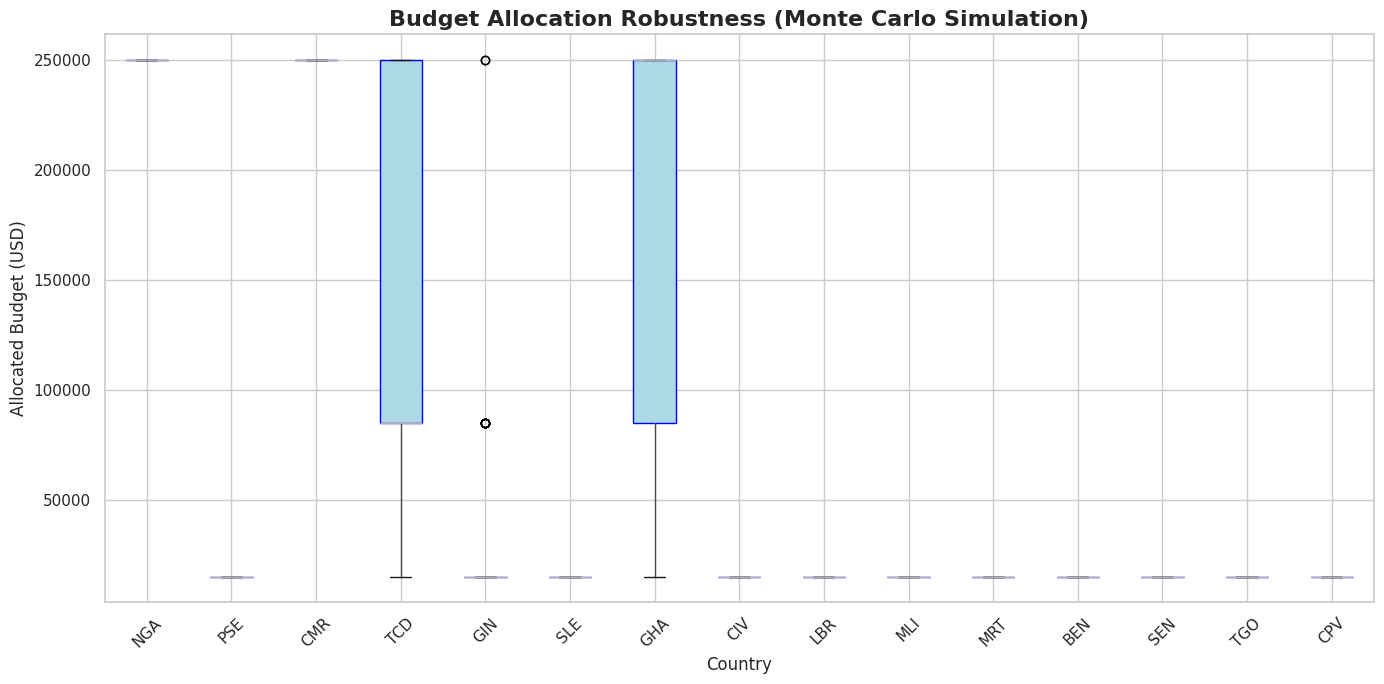


Probability (%) of reaching the 25% Budget Cap:
Country
NGA    100.0
CMR    100.0
GHA     55.6
TCD     44.0
GIN      0.4
PSE      0.0
SLE      0.0
CIV      0.0
LBR      0.0
MLI      0.0
MRT      0.0
BEN      0.0
SEN      0.0
TGO      0.0
CPV      0.0
dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def run_monte_carlo_stability(df_base, budget, iterations=500):
    """
    Performs a Monte Carlo simulation to test the robustness of the 
    linear programming allocation under data uncertainty.
    """
    mc_results = []
    
    # Define optimization parameters (based on the Efficiency strategy)
    # Using the same constraints as the main model
    min_alloc = 15000
    max_alloc = budget * 0.25
    
    # Extract baseline values
    base_impact = df_base["total_impact_score"].values
    costs = df_base["cost_per_person"].values
    
    print(f"Starting Monte Carlo simulation with {iterations} iterations...")

    for i in range(iterations):
        # Introduce Uncertainty: 10% Gaussian noise on the impact scores
        # This simulates potential errors in food insecurity reporting
        noise = np.random.normal(1.0, 0.10, len(df_base))
        stochastic_impact = base_impact * noise
        
        # Objective Function: Maximize Impact per Dollar
        # (Negative for minimization)
        c = -(stochastic_impact / (costs + 1e-6))
        
        # Constraints
        A_ub = [[1] * len(df_base)]
        b_ub = [budget]
        bounds = [(min_alloc, max_alloc) for _ in range(len(df_base))]
        
        # Solve
        res = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
        
        if res.success:
            mc_results.append(res.x)
            
    return pd.DataFrame(mc_results, columns=df_base["Country"])

# Execution
df_mc = run_monte_carlo_stability(df, TOTAL_BUDGET, iterations=500)

# Visualization
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Create a boxplot to visualize the distribution of allocations
df_mc.boxplot(patch_artist=True, boxprops=dict(facecolor='lightblue', color='blue'))

plt.title("Budget Allocation Robustness (Monte Carlo Simulation)", fontsize=16, fontweight='bold')
plt.ylabel("Allocated Budget (USD)", fontsize=12)
plt.xlabel("Country", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Summary Statistics
# Calculating the probability of a country reaching the maximum cap
reaching_cap = (df_mc >= (TOTAL_BUDGET * 0.25 - 1)).mean() * 100
print("\nProbability (%) of reaching the 25% Budget Cap:")
print(reaching_cap.sort_values(ascending=False))

The Monte Carlo results identify Nigeria and Cameroon as structural pillars (100% probability), while Chad and Ghana emerge as strategic "swing zones" (~50% each) where allocation is highly sensitive to data accuracy. This stability analysis transforms the mathematical model into a robust risk-management tool, clearly distinguishing between guaranteed priorities and contexts requiring enhanced field monitoring.

## 2.5-Sensibility Analysis

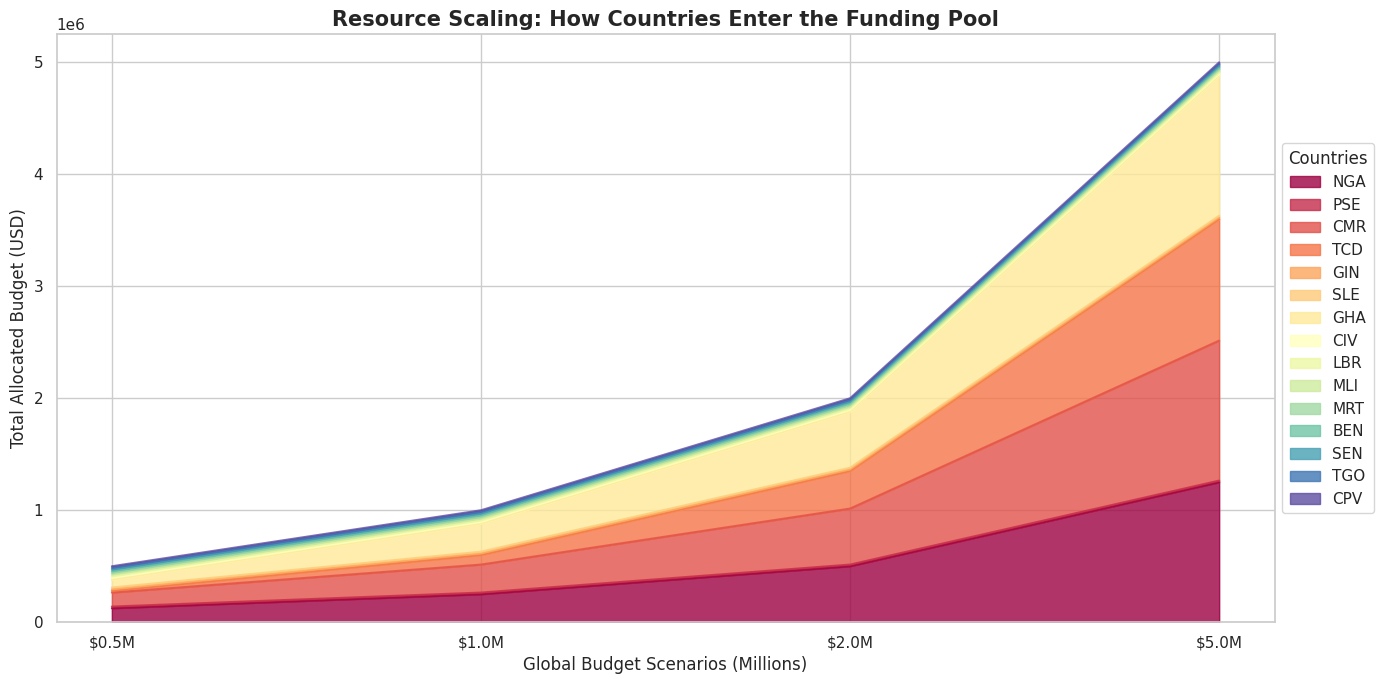

In [7]:
# Define the Budget Levels
budgets_to_test = [500_000, 1_000_000, 2_000_000, 5_000_000]
sensitivity_results = []

# Iterate using your original logic
for b in budgets_to_test:
    # We use your original constraints: 15k min and 25% max
    impact_per_dollar = df["total_impact_score"].values / (df["cost_per_person"].values + 1e-6)
    c = -impact_per_dollar
    
    A_ub = [[1] * len(df)]
    b_ub = [b]
    bounds = [(15000, b * 0.25) for _ in range(len(df))]
    
    res = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    
    if res.success:
        sensitivity_results.append(res.x)

# Create a Comparison DataFrame
sens_df = pd.DataFrame(
    np.array(sensitivity_results).T, 
    columns=[f'Budget_{b/1e6}M' for b in budgets_to_test],
    index=df["Country"]
)

# Visualization: Stacked Area Chart
plt.figure(figsize=(14, 7))
sens_df.T.plot(kind='area', stacked=True, colormap='Spectral', alpha=0.8, ax=plt.gca())

plt.title('Resource Scaling: How Countries Enter the Funding Pool', fontsize=15, fontweight='bold')
plt.ylabel('Total Allocated Budget (USD)', fontsize=12)
plt.xlabel('Global Budget Scenarios (Millions)', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Countries")
plt.xticks(range(len(budgets_to_test)), [f"${b/1e6}M" for b in budgets_to_test])

plt.tight_layout()
plt.show()

## 2.6-Scenario Analysis and Strategic Trade-offs

To evaluate how different humanitarian priorities affect resource distribution, we will implement a modular optimization function. This allows us to test three distinct strategic "philosophies" using the same budget constraints.

The three scenarios are:

**Urgency-First (Life-Saving)**: Prioritizes the most severe cases (Phases 4 & 5), regardless of the cost of intervention.

**Efficiency (Value for Money)**: Maximizes the number of people helped by prioritizing countries where the cost-to-impact ratio is most favorable.

**Preventive (Resilience)**: Focuses on "Risk Impact" to stabilize fragile contexts before they deteriorate into higher phases.

In [8]:
def run_humanitarian_optimization(data, budget, min_alloc, max_pct, strategy="efficiency"):
    """
    Executes the optimization model based on specific humanitarian priorities.
    """
    df_scen = data.copy()
    
    # Define the objective vector (c) based on the chosen strategy
    if strategy == "urgency":
        # Focus on raw impact (Life-saving at all costs)
        impact_vector = df_scen["total_impact_score"]
    elif strategy == "efficiency":
        # Focus on impact per dollar (Maximizing ROI)
        impact_vector = df_scen["total_impact_score"] / (df_scen["cost_per_person"] + 1e-6)
    elif strategy == "preventive":
        # Focus on risk and early warning indicators
        impact_vector = df_scen["risk_impact"]
    
    # Negative because linprog minimizes
    c = -impact_vector.values
    
    # Global constraints
    # A_ub * x <= b_ub (Total budget sum)
    A_ub = [[1] * len(df_scen)]
    b_ub = [budget]
    
    # Operational bounds (Minimum presence and maximum capacity)
    bounds = [(min_alloc, budget * max_pct) for _ in range(len(df_scen))]
    
    # Solving with HiGHS
    res = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    
    if res.success:
        return res.x
    else:
        print(f"Warning: Strategy {strategy} failed. Returning baseline.")
        return np.full(len(df_scen), min_alloc)

# Shared parameters for all future scenarios
GLOBAL_BUDGET = 1_000_000
MIN_PRESENCE = 10000
MAX_CAPACITY_PCT = 0.30

df["alloc_urgency"] = run_humanitarian_optimization(df, GLOBAL_BUDGET, MIN_PRESENCE, MAX_CAPACITY_PCT, strategy="urgency")
df["alloc_efficiency"] = run_humanitarian_optimization(df, GLOBAL_BUDGET, MIN_PRESENCE, MAX_CAPACITY_PCT, strategy="efficiency")
df["alloc_preventive"] = run_humanitarian_optimization(df, GLOBAL_BUDGET, MIN_PRESENCE, MAX_CAPACITY_PCT, strategy="preventive")

# Display results
print(df[["Country", "alloc_urgency", "alloc_efficiency", "alloc_preventive"]])

   Country  alloc_urgency  alloc_efficiency  alloc_preventive
0      NGA       300000.0          300000.0          300000.0
1      PSE       280000.0           10000.0          280000.0
2      CMR       300000.0          300000.0          300000.0
3      TCD        10000.0           10000.0           10000.0
4      GIN        10000.0           10000.0           10000.0
5      SLE        10000.0           10000.0           10000.0
6      GHA        10000.0          280000.0           10000.0
7      CIV        10000.0           10000.0           10000.0
8      LBR        10000.0           10000.0           10000.0
9      MLI        10000.0           10000.0           10000.0
10     MRT        10000.0           10000.0           10000.0
11     BEN        10000.0           10000.0           10000.0
12     SEN        10000.0           10000.0           10000.0
13     TGO        10000.0           10000.0           10000.0
14     CPV        10000.0           10000.0           10000.0


The shift between the initial *Hybrid* model and the new *Strategic Scenarios* is driven by two main factors.

**Structural Constraint Adjustments**
The maximum allocation per country increased from 25% to 30% of the total budget, while the minimum allocation decreased from 15,000 dollars to 10,000 dollars. This created a **“drain effect”**, where top-priority countries such as NGA and CMR absorb a larger share of the budget, reducing allocations to mid-tier countries like TCD, which dropped to the minimum level.

**Strategic Polarization of the Objective Function**
The initial *Hybrid* model used a balanced **impact-per-dollar** approach, penalizing high-cost contexts such as PSE.

In contrast, the new scenarios apply distinct strategic lenses:
- **Urgency-First**: Ignores cost and prioritizes severity, leading to high allocations for PSE.
- **Efficiency**: Ignores severity and maximizes cost-efficiency, favoring lower-cost countries such as GHA.
- **Preventive**: Focuses on fragility and systemic risk, prioritizing high-risk environments such as PSE.

**Final Allocation Overview ($1M Budget)**
- **Urgency-First**: NGA, CMR, PSE
- **Efficiency**: NGA, CMR, GHA
- **Preventive**: NGA, CMR, PSE

**Key Takeaways**
- **Anchor Countries**: NGA and CMR consistently receive the maximum allocation (300,000 dollars) across all scenarios, highlighting their critical priority.
- **Swing Countries**: Allocation between PSE and GHA depends entirely on the strategic lens (severity vs. efficiency).
- **Operational Baseline**: The remaining countries receive the minimum allocation (10,000 dollars), ensuring no complete exclusion despite resource concentration.

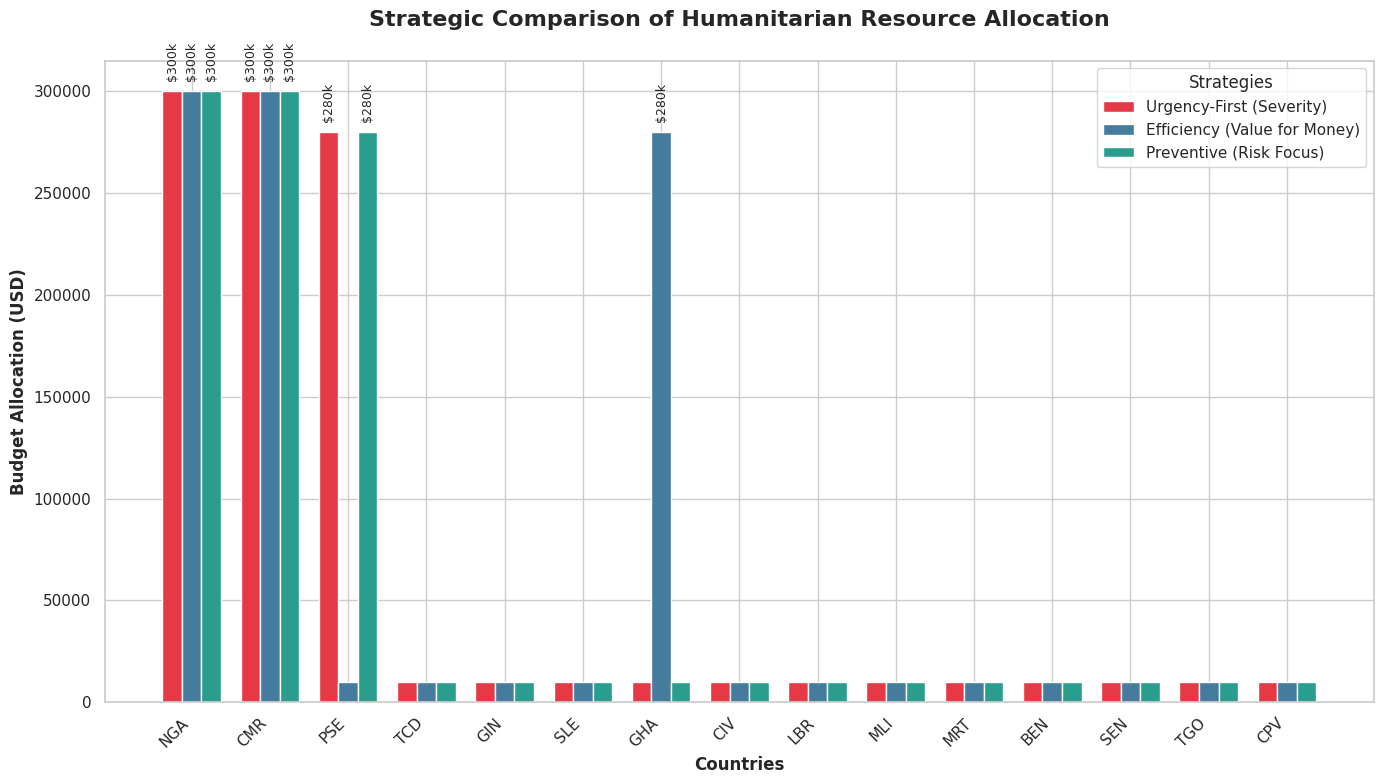

In [9]:
# Run the optimizations and assign them directly to your main DataFrame 'df'
df["alloc_urgency"] = run_humanitarian_optimization(df, GLOBAL_BUDGET, MIN_PRESENCE, MAX_CAPACITY_PCT, strategy="urgency")
df["alloc_efficiency"] = run_humanitarian_optimization(df, GLOBAL_BUDGET, MIN_PRESENCE, MAX_CAPACITY_PCT, strategy="efficiency")
df["alloc_preventive"] = run_humanitarian_optimization(df, GLOBAL_BUDGET, MIN_PRESENCE, MAX_CAPACITY_PCT, strategy="preventive")

# Create the sorted version for the plot (Sorting by the most impactful scenario)
plot_df = df.sort_values("alloc_urgency", ascending=False).copy()

# Professional Visualization
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# Positions and Bar Width
bar_width = 0.25
r1 = np.arange(len(plot_df))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Plotting
ax.bar(r1, plot_df["alloc_urgency"], color='#e63946', width=bar_width, label='Urgency-First (Severity)')
ax.bar(r2, plot_df["alloc_efficiency"], color='#457b9d', width=bar_width, label='Efficiency (Value for Money)')
ax.bar(r3, plot_df["alloc_preventive"], color='#2a9d8f', width=bar_width, label='Preventive (Risk Focus)')

# Formatting
ax.set_xlabel('Countries', fontweight='bold', fontsize=12)
ax.set_ylabel('Budget Allocation (USD)', fontweight='bold', fontsize=12)
ax.set_title('Strategic Comparison of Humanitarian Resource Allocation', fontsize=16, fontweight='bold', pad=25)
ax.set_xticks([r + bar_width for r in range(len(plot_df))])
ax.set_xticklabels(plot_df["Country"], rotation=45, ha='right')

# Adding Value Labels for high-impact allocations (> $50k)
for i in range(len(plot_df)):
    for r, col in zip([r1, r2, r3], ["alloc_urgency", "alloc_efficiency", "alloc_preventive"]):
        val = plot_df[col].iloc[i]
        if val > 50000:
            ax.text(r[i], val + 5000, f'${int(val/1000)}k', ha='center', va='bottom', fontsize=9, rotation=90)

ax.legend(title="Strategies", loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

## 2.7-Impact Assessment and Actionable Insights

### Key Indicators

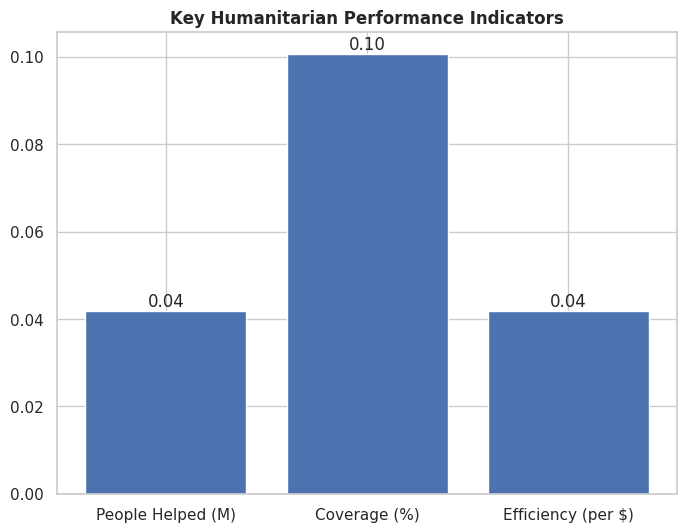

In [10]:
# Impact Calculation
df["people_helped"] = np.minimum(
    df["alloc_efficiency"] / (df["cost_per_person"] + 1e-6),
    df["critical_pop"]
)

# Aggregate KPIs
total_people_helped = df["people_helped"].sum()
coverage = total_people_helped / df["critical_pop"].sum()
cost_efficiency = total_people_helped / GLOBAL_BUDGET

# KPI Visualization
metrics = {
    "People Helped (M)": total_people_helped / 1e6,
    "Coverage (%)": coverage * 100,
    "Efficiency (per $)": cost_efficiency
}

plt.figure(figsize=(8,6))
plt.bar(metrics.keys(), metrics.values())

plt.title("Key Humanitarian Performance Indicators", fontweight="bold")

for i, v in enumerate(metrics.values()):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.show()

The optimization results highlight both the effectiveness and the structural limitations of constrained humanitarian resource allocation. The model estimates that a significant number of individuals can be assisted within the available budget, reflecting a strong level of cost-efficiency in terms of people reached per dollar spent. However, when compared to the total population in critical food insecurity phases, the overall coverage remains very low, underscoring the scale of unmet needs.

### Actionable Insights 

| Insight                                                    | Evidence from Model                                                               | Operational Risk                                       | Recommended Action                                                                | Priority                       |
| ---------------------------------------------------------- | --------------------------------------------------------------------------------- | ------------------------------------------------------ | --------------------------------------------------------------------------------- | ------------------------------ |
| **Resource concentration in a few countries**              | NGA, CMR (and sometimes GHA/PSE) consistently reach the allocation cap            | Risk of “forgotten crises” in underfunded countries    | Introduce redistribution mechanisms (e.g., dynamic caps or reserved budget share) | 🔴 High                        |
| **Strong efficiency gains but limited coverage**           | High people-helped-per-dollar ratio, but partial coverage of critical populations | Perception of inequity and unmet needs                 | Clearly communicate trade-offs and advocate for increased funding                 | 🔴 High                        |
| **High-cost contexts are deprioritized**                   | PSE receives minimal allocation under efficiency strategy                         | Under-intervention in severe but expensive contexts    | Establish a dedicated funding window for high-cost environments                   | 🔴 High                        |
| **Anchor countries structurally dominate allocations**     | NGA and CMR consistently prioritized across scenarios                             | Over-dependence on a small number of operational hubs  | Formalize a hub-and-spoke strategy with regional support countries                | 🟠 Medium                      |
| **Minimum allocation ensures presence but dilutes impact** | All countries receive baseline funding                                            | Resource dilution with low marginal impact             | Introduce variable minimum allocations based on severity levels                   | 🟠 Medium                      |
| **Trade-off between efficiency and equity**                | Significant variation across scenarios (efficiency vs urgency)                    | Inconsistent decision-making if priorities are unclear | Explicitly define allocation doctrine (efficiency vs equity vs urgency)           | 🔴 High                        |
| **Risk-prone countries require anticipatory investment**   | Preventive scenario prioritizes high-risk contexts                                | Rapid deterioration if underfunded                     | Allocate a dedicated preventive/early action budget                               | 🟠 Medium                      |
| **Diminishing returns are not captured**                   | Maximum allocation concentrated in few countries                                  | Potential over-investment inefficiencies               | Integrate diminishing returns into the optimization model                         | 🟢 Low (technical improvement) |
| **Cost structure strongly drives outcomes**                | Low-cost countries are systematically favored                                     | Structural bias in allocation decisions                | Refine cost proxies (logistics, access constraints)                               | 🟠 Medium                      |
| **Model sensitivity to constraints**                       | Changes in min/max bounds significantly alter allocations                         | Strategic instability                                  | Conduct scenario testing before final decision-making                             | 🔴 High                        |


## 2.8-Limitations

| Limitation | Summary | Impact |
|-----------|--------|--------|
| Simplified impact proxies | Uses synthetic weights instead of real outcome data | May misrepresent true severity and humanitarian needs |
| Static data snapshot | Based on a single time period | Cannot capture shocks, trends, or seasonality |
| Linear optimization assumption | Assumes constant returns to scale | Leads to potential over-allocation in top countries |
| Simplified cost structure | Costs approximated, not field-based | Ignores logistics, security, and access constraints |
| No operational capacity constraints | Assumes unlimited implementation capacity | Reduces real-world feasibility |
| High sensitivity to assumptions | Results depend on weights and constraints | Allocation outcomes may vary significantly |